# Synchronization of a single spin ensemble in cavity QED

This simulation is based on the work from Bihui [Synchronization of Interacting Quantum Dipoles](https://arxiv.org/pdf/1502.06055). The dynamics of spins can be (approximately) mapped to a classical Kuramoto model,
$$
\frac{d \phi_a}{d t}=\delta_a+K \sum_{b=1}^N \sin \left[\delta \phi_{b a}\right]
$$
where $K$ is the coupling strength. As $K$ becomes large enough, the system has a synchronization solution, with an order parameter defined as
$$
r e^{i \psi}=\frac{1}{N} \sum_{j=1}^N e^{i \theta_j}.
$$
This order parameter makes sense cause it represents the "mean" oscillating vector of the system. In that paper, the essence of obtaining the steady synchronization is the **collective decay and the indivisual incoherent pump**.

### Without inhomogeneity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

# --- 1. 物理参数设置 (可根据需要调整) ---
N = 200        # 原子数量 (使用向量化技巧后，N=1000也能很快算完)
f = 2.0        # 集体耗散系数 f
Gamma = 1.0    # 独立耗散率 \Gamma
W = 3.2        # 独立泵浦率 W
t_max = 30.0   # 演化总时间

# --- 2. 初始化系统状态 ---
# 在 Bloch 球面上均匀随机分布
# 均匀球面的随机取样: cos(theta) 均匀分布在 [-1, 1], phi 均匀分布在 [0, 2pi]
np.random.seed(42) # 固定随机种子以保证结果可复现
u = np.random.uniform(0, 1, N)
theta_init = np.arccos(1 - 2 * u)
phi_init = np.random.uniform(0, 2 * np.pi, N)

# Spin-1/2 系统的算符期望值范围在 [-1/2, 1/2]
Sz_init = 0.5 * np.cos(theta_init)
Sperp_init = 0.5 * np.sin(theta_init)

# 打包初始条件，供求解器使用
y0 = np.concatenate([Sz_init, Sperp_init, phi_init])

# --- 3. 定义运动方程 (ODE) ---
def spin_dynamics(t, y, N, f, Gamma, W):
    # 解包状态向量
    Sz = y[0:N]
    Sperp = y[N:2*N]
    phi = y[2*N:3*N]
    
    # 【向量化技巧】: 计算全局量，将 O(N^2) 复杂度降至 O(N)
    # X = sum_b S_b^\perp cos(phi_b)
    # Y = sum_b S_b^\perp sin(phi_b)
    X = np.sum(Sperp * np.cos(phi))
    Y = np.sum(Sperp * np.sin(phi))
    
    # 构造 Sigma_c = sum_{b \neq a} S_b^\perp cos(phi_b - phi_a)
    Sigma_c = X * np.cos(phi) + Y * np.sin(phi) - Sperp
    # 构造 Sigma_s = sum_{b \neq a} S_b^\perp sin(phi_b - phi_a)
    Sigma_s = Y * np.cos(phi) - X * np.sin(phi)
    
    # 运动方程计算
    dSz_dt = -(f / N) * Sperp * Sigma_c - Gamma * (0.5 + Sz) + W * (0.5 - Sz)
    dSperp_dt = (f / N) * Sz * Sigma_c - 0.5 * (Gamma + W) * Sperp
    
    # 防止 Sperp -> 0 时相位的导数发散（极点处的奇点），加入 1e-12 保护
    Sperp_safe = np.where(Sperp < 1e-12, 1e-12, Sperp)
    dphi_dt = (f / N) * (Sz / Sperp_safe) * Sigma_s
    
    return np.concatenate([dSz_dt, dSperp_dt, dphi_dt])

# --- 4. 求解微分方程 ---
print(f"开始演化 {N} 个自旋，总时长 t={t_max}...")
sol = solve_ivp(spin_dynamics, [0, t_max], y0, args=(N, f, Gamma, W), 
                method='RK45', t_eval=np.linspace(0, t_max, 500))

# 提取最终时刻状态
Sz_final = sol.y[0:N, -1]
Sperp_final = sol.y[N:2*N, -1]
phi_final = sol.y[2*N:3*N, -1]

# --- 5. 计算 Order Parameter (序参量) ---
# 定义为 Z * exp(i * Phi) = (1/N) * sum_a S_a^\perp * exp(i * phi_a)
order_param_complex = np.mean(Sperp_final * np.exp(1j * phi_final))
Z = np.abs(order_param_complex)
Phi = np.angle(order_param_complex)

print("-" * 30)
print(f"演化完成！")
print(f"Order parameter Z: {Z:.4f}")
print(f"Phase \Phi: {Phi:.4f} rad")
print("-" * 30)



开始演化 200 个自旋，总时长 t=30.0...
------------------------------
演化完成！
Order parameter Z: 0.0000
Phase \Phi: -1.4058 rad
------------------------------


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


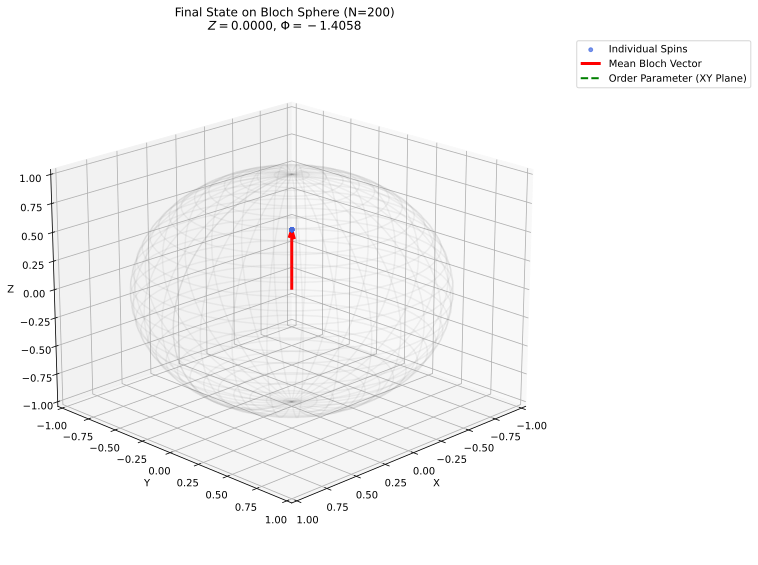

In [2]:
# --- 6. 3D Bloch 球可视化 ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制半透明 Bloch 球壳
u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 60)
x_sphere = np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_sphere = np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_sphere = np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.1)

# 【重点】: 将自旋转换为单位球上的笛卡尔坐标 (自旋本征值为 +- 1/2，乘2使其贴合半径为1的球)
x_final = 2 * Sperp_final * np.cos(phi_final)
y_final = 2 * Sperp_final * np.sin(phi_final)
z_final = 2 * Sz_final

# 1. 点出各个 spin 的最终位置
ax.scatter(x_final, y_final, z_final, color='royalblue', s=15, alpha=0.7, label='Individual Spins')

# 2. 计算平均 Bloch Vector 并画出
# 它的横向分量恰好是 2*Z*cos(Phi) 和 2*Z*sin(Phi)
mean_z = 2 * np.mean(Sz_final)
mean_x = 2 * Z * np.cos(Phi)
mean_y = 2 * Z * np.sin(Phi)

# 画出整体的 Average Bloch Vector (红色箭头)
ax.quiver(0, 0, 0, mean_x, mean_y, mean_z, color='red', linewidth=3, 
          arrow_length_ratio=0.15, label='Mean Bloch Vector')

# 画出横向 Order Parameter 的纯粹投影 (绿色虚线)
ax.quiver(0, 0, 0, mean_x, mean_y, 0, color='green', linestyle='dashed', linewidth=2, 
          arrow_length_ratio=0.15, label='Order Parameter (XY Plane)')

# 设置坐标轴和视角
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Final State on Bloch Sphere (N={N})\n$Z = {Z:.4f}$, $\Phi = {Phi:.4f}$')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.view_init(elev=20, azim=45) # 调整初始视角

plt.tight_layout()
plt.show()

### With inhomogeneity $\delta$

开始演化 200 个不均匀自旋 (Delta_dis= 0.5)，t=50.0...
------------------------------
演化完成！
Order parameter Z: 0.1423
Phase \Phi: 0.4182 rad
------------------------------


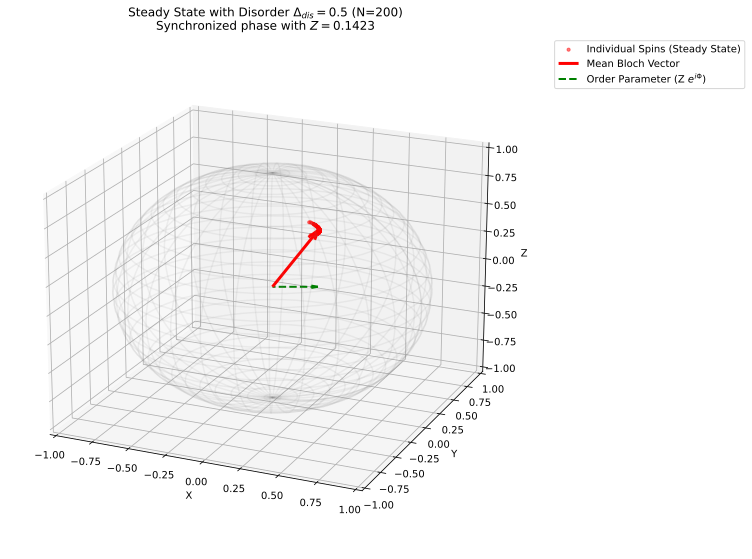

In [3]:
# --- 1. 物理参数设置 ---
N = 200        # 原子数量
f = 10.0       # 集体耗散系数 f (增大 f 以进入同步相)
Gamma = 1.0    # 独立耗散率
W = 3.8        # 独立泵浦率 (接近 Gamma，让 Sz 处于赤道附近，更容易看同步)
t_max = 50.0   # 演化时长 (需要更长一点时间才能让分布稳定)

# ---【重点修改 1/2】: 引入局域失谐 Disorder (Delta_a) ---
# 使用高斯分布产生局域失谐。标准差 Delta_disorder 决定了分布的“宽窄”
# 如果 Delta_disorder = 0.0，你就又会得到一个点的结果。
Delta_disorder = 0.5 # 局域失谐的标准差
np.random.seed(42)  # 固定随机种子
delta_a = np.random.normal(0, Delta_disorder, N) # 每个原子的本征失谐

# --- 2. 初始化系统状态 ---
# 依然是 Bloch 球面上均匀随机分布
u = np.random.uniform(0, 1, N)
theta_init = np.arccos(1 - 2 * u)
phi_init = np.random.uniform(0, 2 * np.pi, N)
# 定义：S = 1/2。
Sz_init = 0.5 * np.cos(theta_init)
Sperp_init = 0.5 * np.sin(theta_init)
y0 = np.concatenate([Sz_init, Sperp_init, phi_init])

# --- 3. 定义运动方程 (ODE) ---
def spin_dynamics_with_disorder(t, y, N, f, Gamma, W, delta_a): # 传入 delta_a
    # 解包
    Sz = y[0:N]
    Sperp = y[N:2*N]
    phi = y[2*N:3*N]
    
    # 向量化技巧计算全局量
    X = np.sum(Sperp * np.cos(phi))
    Y = np.sum(Sperp * np.sin(phi))
    
    Sigma_c = X * np.cos(phi) + Y * np.sin(phi) - Sperp
    Sigma_s = Y * np.cos(phi) - X * np.sin(phi)
    
    # 运动方程计算
    dSz_dt = -(f / N) * Sperp * Sigma_c - Gamma * (0.5 + Sz) + W * (0.5 - Sz)
    dSperp_dt = (f / N) * Sz * Sigma_c - 0.5 * (Gamma + W) * Sperp
    
    Sperp_safe = np.where(Sperp < 1e-12, 1e-12, Sperp)
    
    # ---【重点修改 2/2】: 在相位方程中真正启用 delta_a ---
    # 方程第一项：delta_a(t)
    dphi_dt = delta_a + (f / N) * (Sz / Sperp_safe) * Sigma_s # <--- 修正这里
    
    return np.concatenate([dSz_dt, dSperp_dt, dphi_dt])

# --- 4. 求解微分方程 ---
print(f"开始演化 {N} 个不均匀自旋 (Delta_dis= {Delta_disorder})，t={t_max}...")
sol = solve_ivp(spin_dynamics_with_disorder, [0, t_max], y0, args=(N, f, Gamma, W, delta_a), 
                method='RK45', t_eval=np.linspace(0, t_max, 500))

# 提取最终时刻状态
Sz_final = sol.y[0:N, -1]
Sperp_final = sol.y[N:2*N, -1]
phi_final = sol.y[2*N:3*N, -1]

# --- 5. 计算 Order Parameter ---
order_param_complex = np.mean(Sperp_final * np.exp(1j * phi_final))
Z = np.abs(order_param_complex)
Phi = np.angle(order_param_complex)

print("-" * 30)
print(f"演化完成！")
print(f"Order parameter Z: {Z:.4f}") # 这一次你应该能看到 Z >> 0 了
print(f"Phase \Phi: {Phi:.4f} rad")
print("-" * 30)

# --- 6. 3D Bloch 球可视化 ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制半透明 Bloch 球壳
u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 60)
x_sphere = np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_sphere = np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_sphere = np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.1)

# 自旋笛卡尔坐标 (S=1/2 -> R=1球面)
x_final = 2 * Sperp_final * np.cos(phi_final)
y_final = 2 * Sperp_final * np.sin(phi_final)
z_final = 2 * Sz_final

# 1. 点出各个 spin 的最终位置 (这一次你应该能看到一个 Spread 了！)
ax.scatter(x_final, y_final, z_final, color='red', s=10, alpha=0.5, label='Individual Spins (Steady State)')

# 2. 计算平均 Bloch Vector 并画出
mean_z = 2 * np.mean(Sz_final)
mean_x = 2 * Z * np.cos(Phi)
mean_y = 2 * Z * np.sin(Phi)

# 画出整体的 Average Bloch Vector (红色箭头，其长度代表全局极化)
ax.quiver(0, 0, 0, mean_x, mean_y, mean_z, color='red', linewidth=3, 
          arrow_length_ratio=0.15, label='Mean Bloch Vector')

# 画出横向 Order Parameter 的纯粹投影 (绿色虚线)
ax.quiver(0, 0, 0, mean_x, mean_y, 0, color='green', linestyle='dashed', linewidth=2, 
          arrow_length_ratio=0.15, label='Order Parameter (Z $e^{i\Phi}$)')

# 设置坐标轴和视角
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Steady State with Disorder $\Delta_{{dis}} = {Delta_disorder}$ (N={N})\nSynchronized phase with $Z = {Z:.4f}$')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.view_init(elev=20, azim=Phi*180/np.pi - 90) # 自动旋转视角以便最清晰地观察分布

plt.tight_layout()
plt.show()

### A single experiment (trajectory) with continuous measurement 

import numpy as np
import matplotlib.pyplot as plt

# --- 1. 物理参数 ---
N = 70
Gamma = 1.0
W = 20.0        
f_eff = 50.0
f = f_eff / N
noise_strength = 0.15 # 适度的噪声，用于产生弧线展宽

# --- 2. 初始化 ---
np.random.seed(42)
u = np.random.uniform(0, 1, N)
theta_init = np.arccos(1 - 2 * u)
phi_init = np.random.uniform(0, 2 * np.pi, N)

Sz = 0.5 * np.cos(theta_init)
Sperp = 0.5 * np.sin(theta_init)
phi = phi_init

# --- 3. SDE 演化 (无人工归一化，自旋自然进入球体内部) ---
dt = 0.01
steps = 3000

for _ in range(steps):
    X = np.sum(Sperp * np.cos(phi))
    Y = np.sum(Sperp * np.sin(phi))
    
    Sigma_c = X * np.cos(phi) + Y * np.sin(phi) - Sperp
    Sigma_s = Y * np.cos(phi) - X * np.sin(phi)
    
    # 确定性方程
    dSz_det = -f * Sperp * Sigma_c - Gamma * (0.5 + Sz) + W * (0.5 - Sz)
    dSperp_det = f * Sz * Sigma_c - 0.5 * (Gamma + W) * Sperp
    Sperp_safe = np.where(Sperp < 1e-12, 1e-12, Sperp)
    dphi_det = f * (Sz / Sperp_safe) * Sigma_s
    
    # 加入随机白噪声
    noise_Sz = np.random.normal(0, np.sqrt(dt) * noise_strength, N)
    noise_Sperp = np.random.normal(0, np.sqrt(dt) * noise_strength, N)
    noise_phi = np.random.normal(0, np.sqrt(dt) * noise_strength, N)
    
    # 更新状态 (不强制重归一化！)
    temp_Sz = Sz + dSz_det * dt + noise_Sz
    temp_Sperp = Sperp + dSperp_det * dt + noise_Sperp
    temp_phi = phi + dphi_det * dt + noise_phi
    
    Sz = temp_Sz
    # 确保 Sperp 的物理意义 (不能为负)，若越过原点则相位翻转 pi
    Sperp = np.abs(temp_Sperp)
    phi = np.where(temp_Sperp < 0, temp_phi + np.pi, temp_phi)
    phi = (phi + np.pi) % (2 * np.pi) - np.pi

# --- 4. 计算 Order Parameter ---
order_param = np.mean(Sperp * np.exp(1j * phi))
Z_val = np.abs(order_param)
Phi = np.angle(order_param)

print(f"理论上限 Z_max ~= {1/np.sqrt(8):.4f}")
print(f"当前模拟算得的序参量 Z = {Z_val:.4f}")

# --- 5. 绘图准备 ---
x_final = Sperp * np.cos(phi)
y_final = Sperp * np.sin(phi)
z_final = Sz

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 画出透明球壳 (半径 r = 0.5)
r = 0.5
u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 60)
x_sphere = r * np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_sphere = r * np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_sphere = r * np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.1)

# 1. Individual Spins: 由于混合态效应，这些红点会位于布洛赫球的内部，并形成弧线
ax.scatter(x_final, y_final, z_final, color='#e74c3c', s=25, alpha=0.9, label='Individual Spins')

# 2. Order Parameter 矢量: 严格受限于 Z_val
x_op = Z_val * np.cos(Phi)
y_op = Z_val * np.sin(Phi)
ax.quiver(0, 0, 0, x_op, y_op, 0, color='forestgreen', arrow_length_ratio=0.15, linewidth=4, label=r'Order Parameter $Z e^{i\Phi}$')

# 3. Z轴平均极化
z_mean = np.mean(z_final)
ax.quiver(0, 0, 0, 0, 0, z_mean, color='blue', linestyle='dashed', arrow_length_ratio=0.15, linewidth=4, label=r'Mean $S_z$')

# 投影辅助线
x_mean = np.mean(x_final)
y_mean = np.mean(y_final)
ax.plot([x_mean, x_mean], [y_mean, y_mean], [0, z_mean], color='gray', linestyle=':', linewidth=2)

ax.set_xlim([-r, r]); ax.set_ylim([-r, r]); ax.set_zlim([-r, r])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=15, azim=Phi*180/np.pi - 90)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()